# 00 — Validate Tournament Labels
Run this before any analysis to confirm tier labels are correct.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 130

from eda.utils import (load_tables, enrich_matches, get_working_matches,
                        get_completed_maps, savefig)

tables = load_tables()
matches = enrich_matches(tables['matches'])
working = get_working_matches(matches)


In [2]:
print("=== TIER COUNTS (all matches):")
print(matches['tier'].value_counts(dropna=False))
print()
print(f"=== WORKING DATASET (final, T1+T2): {len(working):,} matches")
print(working['tier'].value_counts())
print()
print("=== REGION DISTRIBUTION:")
print(working.groupby(['tier','region']).size().unstack(fill_value=0))


=== TIER COUNTS (all matches):
tier
tier3            9301
tier2            8716
tier1            7530
NaN              3568
game_changers    3424
collegiate        152
Name: count, dtype: int64

=== WORKING DATASET (final, T1+T2): 28,918 matches
tier
tier3            9184
tier2            8687
tier1            7490
game_changers    3406
collegiate        151
Name: count, dtype: int64

=== REGION DISTRIBUTION:
region         APAC  Americas  Brazil  CIS  China  EMEA  Global  Japan  Korea  \
tier                                                                            
collegiate        0         0       0    0      0     0      76      0      0   
game_changers   200        22     210    0     63  1224       0     97     34   
tier1           674       402     331  167    540  1463      81    244    265   
tier2           121         0     535   17      4  3608       0    383    313   
tier3            40         0      61    0      0   113      14      0      0   

region         LATA

In [3]:
# Spot-check: 15 random rows per tier
for tier in ['tier1', 'tier2', 'game_changers', 'tier3', 'collegiate']:
    sample = working[working['tier']==tier][['tournament','region','event_name']].sample(15, random_state=42)
    print(f"\n=== {tier.upper()} SAMPLE:")
    print(sample.to_string())



=== TIER1 SAMPLE:
                                                tournament  region                                                                                event_name
25928            Champions Tour Korea Stage 2: Challengers   Korea                       Champions Tour Korea Stage 2: Challengers Group Stage: Winner's (A)
24189          Champions Tour LATAM Stage 3: Challengers 1   LATAM                Champions Tour LATAM Stage 3: Challengers 1 Main Event: LAS: Lower Round 2
19172                     Valorant Conquerors Championship     NaN                 Valorant Conquerors Championship Wildcard Qualifier: Upper Bracket Finals
26724          Champions Tour Korea Stage 1: Challengers 3   Korea                           Champions Tour Korea Stage 1: Challengers 3 Main Event: Group A
2341                               Valorant Champions 2025     NaN                                          Valorant Champions 2025 Group Stage: Opening (A)
7354                 Champions Tour 202

In [4]:
# Completed maps
maps = tables['maps']
comp_maps = get_completed_maps(maps, working)
print(f"\n=== Completed maps per tier:")
print(comp_maps['tier'].value_counts())
print(f"Total completed maps: {len(comp_maps):,}")



=== Completed maps per tier:
tier
tier2            18813
tier1            17462
tier3            16343
game_changers     7650
collegiate         319
Name: count, dtype: int64
Total completed maps: 60,587


In [5]:
# Sanity check: team1 win rate ≈ 50%
team1_wr = (comp_maps['map_winner_id'] == comp_maps['team1_id']).mean()
print(f"\nTeam1 map win rate: {team1_wr:.4f}  (expect 0.48–0.56)")
assert 0.47 < team1_wr < 0.58, f"FAIL: team1 win rate {team1_wr:.4f} is suspicious"
print("PASS: team1 win rate looks balanced")



Team1 map win rate: 0.5603  (expect 0.48–0.56)
PASS: team1 win rate looks balanced


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/00_tier_region_distribution.png


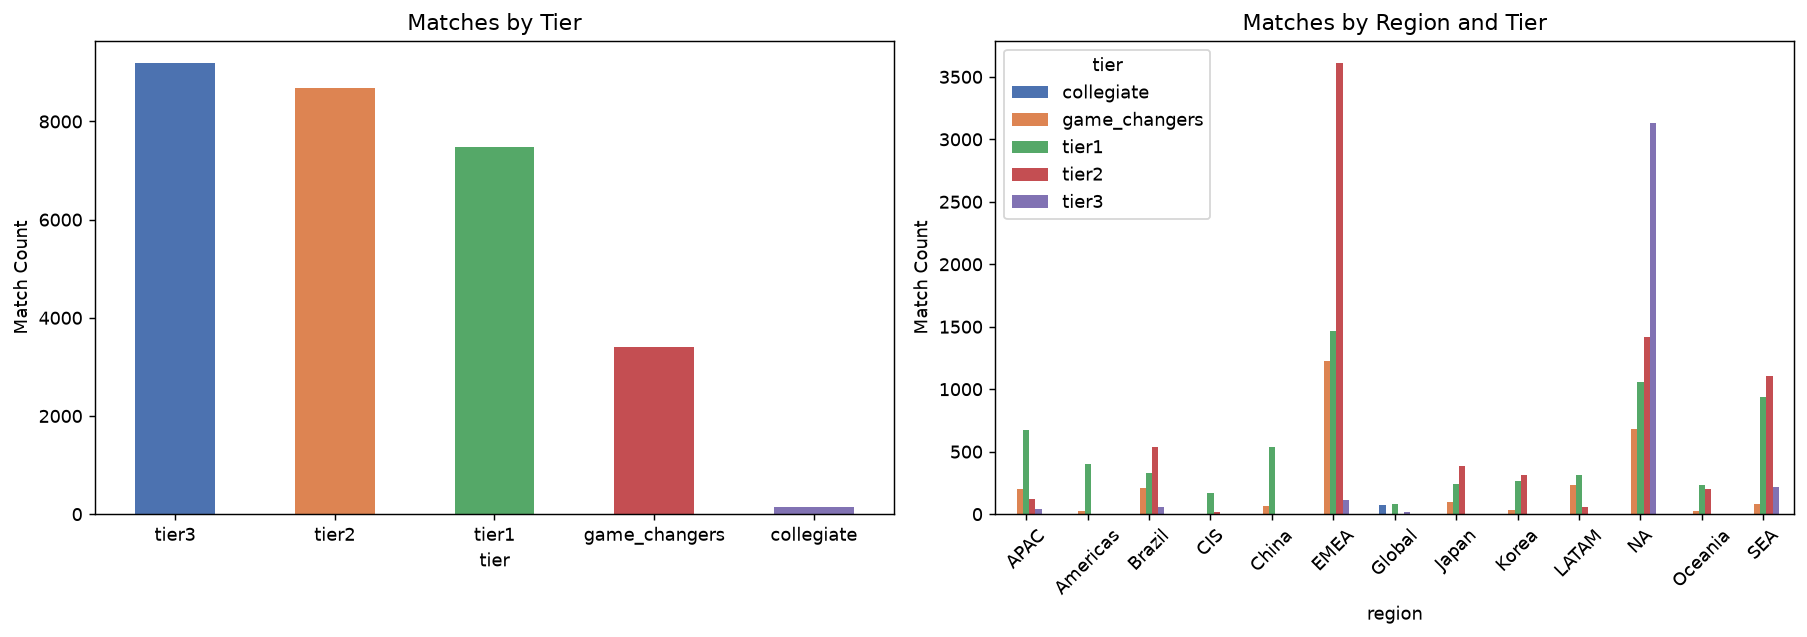

In [6]:
# Plot: match count by tier and region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
working['tier'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3'])
axes[0].set_title('Matches by Tier')
axes[0].set_ylabel('Match Count')
axes[0].tick_params(axis='x', rotation=0)

region_tier = working.groupby(['region','tier']).size().unstack(fill_value=0)
region_tier.plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3'])
axes[1].set_title('Matches by Region and Tier')
axes[1].set_ylabel('Match Count')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
savefig(fig, '00_tier_region_distribution')
plt.show()
